In [2]:
!nvidia-smi

Tue Sep  1 03:26:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# import torch, triton, numpy and matplotlib
import torch
from torch.utils.cpp_extension import load_inline # for loading cuda code
import triton
import triton.language as tl
import numpy as np
import matplotlib.pyplot as plt

# print versions of the libraries
print(f"torch.__version__: {torch.__version__}")
print(f"triton.__version__: {triton.__version__}")
print(f"np.__version__: {np.__version__}")

torch.__version__: 2.11.0+cu128
triton.__version__: 3.6.0
np.__version__: 2.1.3


In [4]:
# 1. default torch square function
x=torch.randn(1000)
a=torch.square(x)

# 2. Simple Square Function
def square_simple(x):
    return x*x

# 3. torch.pow (commented out for now)
def square_pow(x):
    return torch.pow(x, 2)


In [5]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 15.3 MB/s eta 0:00:00


In [6]:

# 4. Custom CUDA Square Kernel

cpp_source = r"""
#include <torch/extension.h>

torch::Tensor square_cuda(torch::Tensor input);
"""

cuda_source = r"""

#include <torch/extension.h>
// Define the square_kernel function
__global__ void square_kernel(
    const float *input,
    float *output,
    int n
)
{
    // Get the global thread ID/index from the block and thread IDs
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // If the thread ID is greater than the number of elements, then you will face and OOB error
    if (idx < n) {
        // Square the input element and store it in the output array
        output[idx] = input[idx] * input[idx];
    }
}

// Define the square_cuda function
torch::Tensor square_cuda(torch::Tensor input) {
    input = input.contiguous(); // make the input tensor contiguous in memory
    // Get the number of elements in the input tensor
    int n = input.numel();

    // Create an output tensor with the same shape as the input tensor
    torch::Tensor output = torch::empty_like(input);

    // use 256 threads per block
    int threads = 256;

    // calculate the number of blocks needed
    int blocks = (n + threads - 1) / threads;

    //call the cuda kernel
    square_kernel<<<blocks, threads>>>(
        input.data_ptr<float>(),
        output.data_ptr<float>(),
        n
    );

    // return the output tensor
    return output;
}
"""

# use load_inline to load the kernel
module = load_inline(
    name="square_kernel",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=["square_cuda"],
    verbose=True
)



In [7]:
# 5. triton square kernel
# in order to use triton to write a square kernel, we need to write a jit function and a launcher function.
# the jit function will be used to define the kernel and the launcher function will be used to launch the kernel.

# jit function
@triton.jit
def square_kernel(
    x_ptr,# pointer to the input array
    y_ptr,# pointer to the output array
    n_elements,# number of elements in the input array
    BLOCK_SIZE: tl.constexpr # block size
):
    '''
    This is the kernel body. This kernel is a simple square kernel that squares the input elements.
    '''

    # get the program id
    pid = tl.program_id(0) # gives program id to the instance
    
    # get the offsets of the thread in the block
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)

    # apply mask to avoid out of bounds access
    mask = offsets < n_elements
    
    # load the input elements within the bounds made by the mask
    x = tl.load(x_ptr + offsets, mask=mask)

    # square the input elements
    y = x * x
    
    # store the output elements
    tl.store(y_ptr + offsets, y, mask=offsets < n_elements)

# launcher function for the triton square kernel
def square_triton(x):
    y = torch.empty_like(x) # create an empty tensor with the same shape as x
    n_elements = x.numel() # get the number of elements in x
    BLOCK_SIZE = 1024 # set the block size
    # get number of grids
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)
    square_kernel[grid](x, y, n_elements, BLOCK_SIZE=BLOCK_SIZE) # launch the kernel
    return y




In [8]:
#6. torch.compile version
square_compiled = torch.compile(square_simple)

#7. torch.compile version with triton
square_triton_compiled = torch.compile(square_triton)

In [9]:
N=[2**i for i in [10,14,18,22,26]]

Our goal now is to profile for the latency, effective bandwidth, number of kernels launched, generated code, nsight compute occupancy

Effective Bandwidth = 8N/Tseconds

Latency and effective bandwidth needs to calculated from a benchmark method

In [10]:
impls = {
    "torch.square": torch.square,
    "x*x": square_simple,
    "torch.pow": square_pow,
    "cuda": module.square_cuda,
    "triton": square_triton,
    "compile(x*x)": square_compiled,
    "compile(triton)": square_triton_compiled,
}

latency_ms = {name: [] for name in impls}
bw_gbs = {name: [] for name in impls}

# benchmark function to calculate the latency, effective bandwidth, number of kernels launched, generated code, nsight compute occupancy
def benchmark(func, x, iters=100):
    for _ in range(10):
        func(x)
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(iters):
        func(x)
    end.record()
    torch.cuda.synchronize()
    ms = start.elapsed_time(end) / iters
    n = x.numel()
    gbps = (8 * n) / (ms * 1e-3) / 1e9
    return ms, gbps
    

In [11]:
for n in N:
    x = torch.randn(n, device="cuda")
    for name, fn in impls.items():
        ms, gbps = benchmark(fn, x)
        latency_ms[name].append(ms)
        bw_gbs[name].append(gbps)

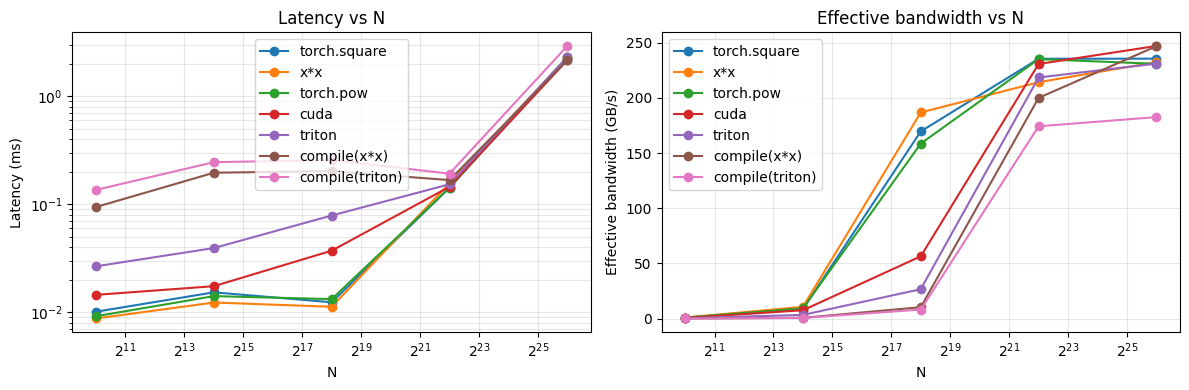

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in impls:
    axes[0].plot(N, latency_ms[name], marker="o", label=name)
    axes[1].plot(N, bw_gbs[name], marker="o", label=name)
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("N")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Latency vs N")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("N")
axes[1].set_ylabel("Effective bandwidth (GB/s)")
axes[1].set_title("Effective bandwidth vs N")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

nsight compute occupancy

In [15]:
import subprocess
import sys
from pathlib import Path

OCC_METRICS = ",".join([
    "sm__warps_active.avg.pct_of_peak_sustained_active",
    "launch__occupancy_limit_blocks",
    "launch__occupancy_limit_registers",
    "launch__occupancy_limit_shared_mem",
    "launch__block_size",
    "launch__grid_size",
    "launch__registers_per_thread",
    "launch__waves_per_multiprocessor",
])

KERNEL_REGEX = {
    "cuda": r"regex:square_kernel",
    "triton": r"regex:square_kernel",
}

SKIP = {"compile(x*x)", "compile(triton)"}

# Colab cwd is /content; this repo file is not uploaded. Write it here.
SQUARE_NCU_SRC = r'''
import argparse
import torch
import triton
import triton.language as tl
from torch.utils.cpp_extension import load_inline

_cuda_module = None


def square_simple(x):
    return x * x


def square_pow(x):
    return torch.pow(x, 2)


@triton.jit
def square_kernel(x_ptr, y_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    tl.store(y_ptr + offsets, x * x, mask=mask)


def square_triton(x):
    y = torch.empty_like(x)
    n_elements = x.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)
    square_kernel[grid](x, y, n_elements, BLOCK_SIZE=1024)
    return y


def square_cuda(x):
    global _cuda_module
    if _cuda_module is None:
        cpp_source = r"""
        #include <torch/extension.h>
        torch::Tensor square_cuda(torch::Tensor input);
        """
        cuda_source = r"""
        #include <torch/extension.h>
        __global__ void square_kernel(const float *input, float *output, int n) {
            int idx = blockIdx.x * blockDim.x + threadIdx.x;
            if (idx < n) {
                output[idx] = input[idx] * input[idx];
            }
        }
        torch::Tensor square_cuda(torch::Tensor input) {
            input = input.contiguous();
            int n = input.numel();
            torch::Tensor output = torch::empty_like(input);
            int threads = 256;
            int blocks = (n + threads - 1) / threads;
            square_kernel<<<blocks, threads>>>(
                input.data_ptr<float>(), output.data_ptr<float>(), n);
            return output;
        }
        """
        _cuda_module = load_inline(
            name="square_kernel_ncu",
            cpp_sources=cpp_source,
            cuda_sources=cuda_source,
            functions=["square_cuda"],
            verbose=False,
        )
    return _cuda_module.square_cuda(x)


KERNELS = {
    "torch.square": torch.square,
    "x*x": square_simple,
    "torch.pow": square_pow,
    "cuda": square_cuda,
    "triton": square_triton,
}


def main(kernel_choice: str, n: int):
    fn = KERNELS[kernel_choice]
    x = torch.randn(n, device="cuda")
    for _ in range(10):
        fn(x)
    torch.cuda.synchronize()
    fn(x)
    torch.cuda.synchronize()


if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--kernel", required=True, choices=list(KERNELS))
    p.add_argument("--n", type=int, required=True)
    args = p.parse_args()
    main(args.kernel, args.n)
'''

SCRIPT = Path("square_ncu.py")
SCRIPT.write_text(SQUARE_NCU_SRC)
print(f"wrote {SCRIPT.resolve()}")


def ncu_occupancy(kernel_choice: str, n: int) -> str:
    if kernel_choice in SKIP:
        return f"skip {kernel_choice}: extra inductor kernels, not useful for occupancy"

    cmd = [
        "ncu", "--csv", "--page", "raw",
        "--metrics", OCC_METRICS,
        "--launch-skip", "10",
        "--launch-count", "1",
        "--kernel-name-base", "demangled",
    ]
    regex = KERNEL_REGEX.get(kernel_choice)
    if regex:
        cmd += ["--kernel-name", regex]
    cmd += ["--", sys.executable, str(SCRIPT.resolve()), "--kernel", kernel_choice, "--n", str(n)]
    try:
        return subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
    except subprocess.CalledProcessError as e:
        return f"ncu failed ({e.returncode}):\n{e.output}"


In [16]:
for n in N:
    for name in impls:
        print(f"ncu_occupancy({name}, {n})")
        print(ncu_occupancy(name, n))
        print("\n")


ncu_occupancy(torch.square, 1024)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(x*x, 1024)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(torch.pow, 1024)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(cuda, 1024)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(triton, 1024)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(compile(x*x), 1024)
skip compile(x*x): extra inductor kernels, not useful for occupancy


ncu_occupancy(compile(triton), 1024)
skip compile(triton): extra inductor kernels, not useful for occupancy


ncu_occupancy(torch.square, 16384)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(x*x, 16384)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(torch.pow, 16384)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(cuda, 16384)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy(triton, 16384)
missing /content/square_ncu.py (cwd=/content)


ncu_occupancy